# Random Forest with Extended Features for Nonlinear CAPM

This notebook builds an extended-feature Random Forest model to predict next-month **excess returns** at the stock level, using:
- Fama–French style factors (Mkt-RF, SMB, HML, RMW, CMA, Mom)
- Stock-level technical characteristics (momentum, volatility, turnover, size, price)
- Macro factors (from `macro_index.csv`)

The goal is to reduce overfitting and improve out-of-sample performance compared with a basic Random Forest model.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.dpi'] = 120


## 1. Load CRSP + factors + macro data

This cell assumes your data files are stored under a `../data` folder:
- `crsp_msf_with_factors.parquet` (or `.csv`)
- `macro_index.csv`

If your paths are different, please adjust `DATA_DIR` or filenames accordingly.

In [32]:
DATA_DIR = Path('../data')

# ---- Load CRSP + factors ----
crsp_parquet = DATA_DIR / 'crsp_msf_with_factors.parquet'
crsp_csv = DATA_DIR / 'crsp_msf_with_factors.csv'

if crsp_parquet.exists():
    chars = pd.read_parquet(crsp_parquet)
elif crsp_csv.exists():
    chars = pd.read_csv(crsp_csv)
else:
    raise FileNotFoundError('Could not find crsp_msf_with_factors parquet or csv in ../data')

# Ensure date is datetime
chars['date'] = pd.to_datetime(chars['date'])

# ---- Load macro data ----
macro_path = DATA_DIR / 'macro_index.csv'
if not macro_path.exists():
    raise FileNotFoundError('Could not find macro_index.csv in ../data')

macro = pd.read_csv(macro_path)
macro['date'] = pd.to_datetime(macro['date'])

macro_feature_cols = [c for c in macro.columns if c != 'date']
chars.shape, macro.shape

((1288566, 20), (1848, 57))

## 2. Merge macro factors and construct target `y_next`

- Compute **excess return** = `ret_adj - RF`
- Construct **next-month excess return** `y_next` within each stock (`permno`)
- Merge macro factors by month

In [33]:
# Merge macro data on date
df = chars.merge(macro, on='date', how='left')

# Basic target construction: excess return and next-month excess return
if 'ret_adj' in df.columns:
    ret_col = 'ret_adj'
elif 'ret' in df.columns:
    ret_col = 'ret'
else:
    raise KeyError('Expected a return column named ret_adj or ret.')

if 'RF' not in df.columns:
    raise KeyError('Expected risk-free rate column RF in the dataset.')

df['excess_ret'] = df[ret_col] - df['RF']

# Sort by stock and time
df = df.sort_values(['permno', 'date']).reset_index(drop=True)

# Next-month excess return as target (y_next)
df['y_next'] = df.groupby('permno')['excess_ret'].shift(-1)

df[['permno', 'date', 'excess_ret', 'y_next']].head()

,permno,date,excess_ret,y_next
0,10001,2000-01-01,-0.454118,-0.414615
1,10001,2000-02-01,-0.414615,-0.485758
2,10001,2000-03-01,-0.485758,-0.448281
3,10001,2000-04-01,-0.448281,-0.523166
4,10001,2000-05-01,-0.523166,-0.372332


## 3. Feature engineering

We construct richer stock-level features using only **information available up to time _t_** for predicting `y_next` at time _t+1_:

**From CRSP-level data:**
- Size (log market equity)
- Price level (log |prc|)
- Turnover level and 3-month mean / volatility
- Return volatility (3m, 12m)
- Simple momentum (1m, 3m, 6m, 12m) using lagged returns

These will be combined with:
- Fama–French style factors already in the dataset (Mkt-RF, SMB, HML, RMW, CMA, Mom)
- Macro factors from `macro_index.csv`

In [34]:
# Group by stock for rolling features
g = df.groupby('permno', group_keys=False)

# ---- Size & price ----
if 'market_equity' in df.columns:
    df['size'] = np.log(df['market_equity'].replace({0: np.nan}))
else:
    df['size'] = np.nan

if 'prc' in df.columns:
    df['log_price'] = np.log(df['prc'].abs().replace({0: np.nan}))
else:
    df['log_price'] = np.nan

# ---- Turnover features ----
if 'turnover' in df.columns:
    df['turnover'] = df['turnover']
    df['turnover_mean_3m'] = g['turnover'].apply(
        lambda x: x.shift(1).rolling(3, min_periods=2).mean()
    )
    df['turnover_vol_3m'] = g['turnover'].apply(
        lambda x: x.shift(1).rolling(3, min_periods=2).std()
    )
else:
    df['turnover'] = np.nan
    df['turnover_mean_3m'] = np.nan
    df['turnover_vol_3m'] = np.nan

# ---- Return volatility ----
df['ret_vol_3m'] = g[ret_col].apply(
    lambda x: x.shift(1).rolling(3, min_periods=2).std()
)
df['ret_vol_12m'] = g[ret_col].apply(
    lambda x: x.shift(1).rolling(12, min_periods=6).std()
)

# ---- Simple momentum (rolling mean of past returns) ----
for window in [1, 3, 6, 12]:
    df[f'mom_{window}m'] = g[ret_col].apply(
        lambda x, w=window: x.shift(1).rolling(w, min_periods=max(1, w//2)).mean()
    )

feature_preview_cols = [
    'permno', 'date', ret_col, 'excess_ret', 'y_next',
    'size', 'log_price', 'turnover', 'turnover_mean_3m', 'turnover_vol_3m',
    'ret_vol_3m', 'ret_vol_12m', 'mom_1m', 'mom_3m', 'mom_6m', 'mom_12m'
]
df[feature_preview_cols].head()

,permno,date,ret_adj,excess_ret,y_next,size,log_price,turnover,turnover_mean_3m,turnover_vol_3m,ret_vol_3m,ret_vol_12m,mom_1m,mom_3m,mom_6m,mom_12m
0,10001,2000-01-01,-0.044118,-0.454118,-0.414615,9.898789,2.094946,0.164490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,2000-02-01,0.015385,-0.414615,-0.485758,9.914057,2.110213,0.090612,NaN,NaN,NaN,NaN,-0.044118,-0.044118,NaN,NaN
2,10001,2000-03-01,-0.015758,-0.485758,-0.448281,9.888983,2.079442,0.293425,0.127551,0.052239,0.042075,NaN,0.015385,-0.014367,NaN,NaN
3,10001,2000-04-01,0.011719,-0.448281,-0.523166,9.900633,2.091092,0.106737,0.182842,0.102645,0.029762,NaN,-0.015758,-0.014830,-0.014830,NaN
4,10001,2000-05-01,-0.023166,-0.523166,-0.372332,9.877195,2.067654,0.089692,0.163592,0.112728,0.017021,NaN,0.011719,0.003782,-0.008193,NaN


## 4. Select feature set and build modeling dataset

We now choose the features to feed into the Random Forest model:

- Fama–French style factors: `Mkt-RF`, `SMB`, `HML`, `RMW`, `CMA`, `Mom`
- Stock characteristics engineered above
- Macro factors from `macro_index.csv`

Target: `y_next` (next-month excess return).

In [35]:
# Base factor features (if available)
factor_cols = [c for c in ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom'] if c in df.columns]

# Stock-level engineered features
stock_feature_cols = [
    'size', 'log_price',
    'turnover', 'turnover_mean_3m', 'turnover_vol_3m',
    'ret_vol_3m', 'ret_vol_12m',
    'mom_1m', 'mom_3m', 'mom_6m', 'mom_12m'
]

# Macro features loaded earlier
all_macro_cols = [c for c in macro_feature_cols if c in df.columns]

feature_cols = factor_cols + stock_feature_cols + all_macro_cols
print('Number of features:', len(feature_cols))
print('Feature list:')
feature_cols

Number of features: 72
Feature list:


['Mkt-RF',
 'SMB',
 'HML',
 'RMW',
 'CMA',
 'Mom',
 'size',
 'log_price',
 'turnover',
 'turnover_mean_3m',
 'turnover_vol_3m',
 'ret_vol_3m',
 'ret_vol_12m',
 'mom_1m',
 'mom_3m',
 'mom_6m',
 'mom_12m',
 'price',
 'd12',
 'e12',
 'retx',
 'AAA',
 'BAA',
 'lty',
 'ltr',
 'corpr',
 'tbl',
 'Rfree',
 'd/p',
 'd/y',
 'e/p',
 'd/e',
 'b/m',
 'tms',
 'dfy',
 'dfr',
 'infl',
 'eqis',
 'ntis',
 'svar',
 'cay',
 'i/k',
 'csp',
 'pce',
 'vp',
 'impvar',
 'vrp',
 'govik',
 'lzrt',
 'skew',
 'crdstd',
 'ogap',
 'wtexas',
 'accrul',
 'cfacc',
 'sntm',
 'ndrbl',
 'skvw',
 'tail',
 'fbm',
 'dtoy',
 'dtoat',
 'ygap',
 'rdsp',
 'rsvix',
 'gpce',
 'gip',
 'tchi',
 'house',
 'avgcor',
 'shtint',
 'disag']

In [36]:
# Drop rows without target or with all-NaN features
model_df = df.dropna(subset=['y_next']).copy()

# Clip extreme target values (helps reduce impact of outliers)
y_raw = model_df['y_next']
y = y_raw.clip(-0.3, 0.3)
X = model_df[feature_cols]

model_df[['date', 'permno', 'y_next']].head(), X.shape

(        date  permno    y_next
 0 2000-01-01   10001 -0.414615
 1 2000-02-01   10001 -0.485758
 2 2000-03-01   10001 -0.448281
 3 2000-04-01   10001 -0.523166
 4 2000-05-01   10001 -0.372332,
 (1275775, 72))

## 5. Time-based train/test split

To avoid look-ahead bias, we split the data by **time**, not randomly.

We:
- Sort unique dates
- Use the first ~80% of months as the training period
- Use the remaining ~20% as the test period

In [44]:
unique_dates = np.sort(model_df['date'].unique())
split_idx = int(len(unique_dates) * 0.6)
cutoff_date = unique_dates[split_idx]
print('First date:', unique_dates[0])
print('Cutoff date for train/test split:', cutoff_date)
print('Last date:', unique_dates[-1])

train_mask = model_df['date'] <= cutoff_date
test_mask = model_df['date'] > cutoff_date

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

X_train.shape, X_test.shape

First date: 2000-01-01T00:00:00.000000000
Cutoff date for train/test split: 2014-12-01T00:00:00.000000000
Last date: 2024-11-01T00:00:00.000000000


((824047, 72), (451728, 72))

## 6. Helper functions: evaluation and plots

We define:
- `evaluate_model` to compute R², RMSE, MAE on train and test sets
- `plot_pred_vs_actual` to visualize predicted vs. actual returns
- `capm_curve_plot` to trace the non-linear response of expected excess return to `Mkt-RF` (holding other features at their median)

In [45]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """Return a metrics dict for a trained model."""
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # 舊版 sklearn 不支援 squared=False，所以自己開平方根
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)

    metrics = {
        'model': name,
        'r2_train': r2_score(y_train, y_pred_train),
        'r2_test': r2_score(y_test, y_pred_test),
        'rmse_train': np.sqrt(mse_train),
        'rmse_test': np.sqrt(mse_test),
        'mae_train': mean_absolute_error(y_train, y_pred_train),
        'mae_test': mean_absolute_error(y_test, y_pred_test),
    }
    return metrics


def plot_pred_vs_actual(y_true, y_pred, title='Predicted vs Actual'):
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.25)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, linestyle='--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def capm_curve_plot(model, X_ref, feature_name='Mkt-RF', model_name='Random Forest (extended)'):
    """Plot how predicted excess return changes with Mkt-RF, holding other features at their median.

    Parameters
    ----------
    model : fitted sklearn model / pipeline
    X_ref : DataFrame used to compute feature medians
    feature_name : str
        Name of the factor to vary (default 'Mkt-RF').
    model_name : str
        Label used in the plot title.
    """
    if feature_name not in X_ref.columns:
        raise KeyError(f'Feature {feature_name} not in X_ref columns.')

    # Base point: median across the reference sample
    base = X_ref.median(numeric_only=True)

    # Grid for the chosen factor
    x_min = X_ref[feature_name].quantile(0.01)
    x_max = X_ref[feature_name].quantile(0.99)
    grid = np.linspace(x_min, x_max, 100)

    # Build grid DataFrame: same medians, varying only the chosen factor
    X_grid = pd.DataFrame(np.tile(base.values, (len(grid), 1)), columns=base.index)
    X_grid[feature_name] = grid

    y_hat = model.predict(X_grid)

    plt.figure(figsize=(6, 4))
    plt.plot(grid, y_hat)
    plt.axhline(0.0, color='black', linewidth=1)
    plt.xlabel(feature_name)
    plt.ylabel('Predicted excess return')
    plt.title(f'Nonlinear CAPM curve: {model_name}')
    plt.tight_layout()
    plt.show()

## 7. Fit Random Forest with extended features

We now fit a **regularized** Random Forest model designed to reduce overfitting:

- Moderate tree depth (`max_depth`)
- Larger minimum leaf size (`min_samples_leaf`)
- Subsampled features and observations per tree (`max_features`, `max_samples`)
- OOB (out-of-bag) score as an internal generalization check

In [46]:
'''
rf_ext = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=100,
    max_features=0.3,        # fraction of features
    bootstrap=True,
    max_samples=0.7,
    oob_score=True,
    n_jobs=-1,
    random_state=42,
)
'''
rf_ext = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=100,
    # 舊版 sklearn 對 max_features 用字串最穩陣，例如 'sqrt' 或 'auto'
    max_features='sqrt',
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=42,
)
pipe_rf_ext = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('rf', rf_ext),
])

pipe_rf_ext.fit(X_train, y_train)

metrics_rf_ext = evaluate_model('RandomForest_extended', pipe_rf_ext, X_train, y_train, X_test, y_test)
metrics_rf_ext

/opt/anaconda3/envs/fyp312/lib/python3.12/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['price' 'd12' 'e12' 'retx' 'AAA' 'BAA' 'lty' 'ltr' 'corpr' 'tbl' 'Rfree'
 'd/p' 'd/y' 'e/p' 'd/e' 'b/m' 'tms' 'dfy' 'dfr' 'infl' 'eqis' 'ntis'
 'svar' 'cay' 'i/k' 'csp' 'pce' 'vp' 'impvar' 'vrp' 'govik' 'lzrt' 'skew'
 'crdstd' 'ogap' 'wtexas' 'accrul' 'cfacc' 'sntm' 'ndrbl' 'skvw' 'tail'
 'fbm' 'dtoy' 'dtoat' 'ygap' 'rdsp' 'rsvix' 'gpce' 'gip' 'tchi' 'house'
 'avgcor' 'shtint' 'disag']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/envs/fyp312/lib/python3.12/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['price' 'd12' 'e12' 'retx' 'AAA' 'BAA' 'lty' 'ltr' 'corpr' 'tbl' 'Rfree'
 'd/p' 'd/y' 'e/p' 'd/e' 'b/m' 'tms' 'dfy' 'dfr' 'infl' 'eqis' 'ntis'
 'svar' 'cay' 'i/k' 'csp' 'pce' 'vp' 'impvar' 'vrp' 'govik' 'lzrt' 'skew'
 'cr

{'model': 'RandomForest_extended',
 'r2_train': 0.26433814018403345,
 'r2_test': -0.07333472003214703,
 'rmse_train': np.float64(0.14108276179725776),
 'rmse_test': np.float64(0.16669486693349342),
 'mae_train': 0.11359602801095482,
 'mae_test': 0.13925273477182948}

## 8. OOB score and feature importance

We check:
- OOB R² as an additional gauge of generalization
- Feature importances from the Random Forest estimator

In [47]:
rf_fitted = pipe_rf_ext.named_steps['rf']
imputer = pipe_rf_ext.named_steps['impute']

print('OOB R^2:', rf_fitted.oob_score_)

# imputer.statistics_ 對應原本 feature_cols 順序
stats = imputer.statistics_

# 有啲 column 係全 NaN → statistics_ 會係 np.nan → 嗰啲係被 skip 嘅 features
valid_mask = ~np.isnan(stats)

# 真正入咗 RandomForest 嘅 feature 名
valid_feature_cols = np.array(feature_cols)[valid_mask]

importances = rf_fitted.feature_importances_

print("len(importances) =", len(importances))
print("len(valid_feature_cols) =", len(valid_feature_cols))

fi = pd.Series(importances, index=valid_feature_cols).sort_values(ascending=False)
fi.head(20)

OOB R^2: 0.26355089246137986
len(importances) = 17
len(valid_feature_cols) = 17


HML                 0.216495
Mkt-RF              0.195015
RMW                 0.175396
CMA                 0.161027
Mom                 0.121227
SMB                 0.089539
mom_12m             0.012584
ret_vol_12m         0.010142
mom_6m              0.003581
log_price           0.003465
mom_3m              0.003081
turnover            0.002530
mom_1m              0.002293
turnover_mean_3m    0.001301
ret_vol_3m          0.001047
size                0.001036
turnover_vol_3m     0.000241
dtype: float64

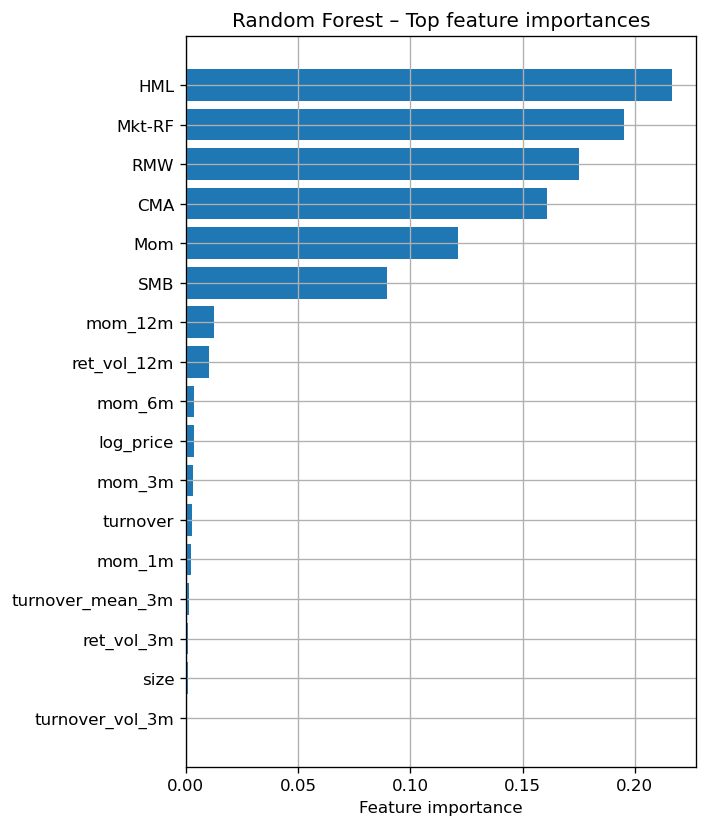

In [48]:
# Plot top 20 features
top_n = 20
fi_head = fi.head(top_n).iloc[::-1]  # reverse for nicer barh

plt.figure(figsize=(6, 0.3 * top_n + 1))
plt.barh(fi_head.index, fi_head.values)
plt.xlabel('Feature importance')
plt.title('Random Forest – Top feature importances')
plt.tight_layout()
plt.show()

## 9. Predicted vs. actual (test set)

Visualize how well the extended Random Forest matches realized next-month excess returns on the test set.

/opt/anaconda3/envs/fyp312/lib/python3.12/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['price' 'd12' 'e12' 'retx' 'AAA' 'BAA' 'lty' 'ltr' 'corpr' 'tbl' 'Rfree'
 'd/p' 'd/y' 'e/p' 'd/e' 'b/m' 'tms' 'dfy' 'dfr' 'infl' 'eqis' 'ntis'
 'svar' 'cay' 'i/k' 'csp' 'pce' 'vp' 'impvar' 'vrp' 'govik' 'lzrt' 'skew'
 'crdstd' 'ogap' 'wtexas' 'accrul' 'cfacc' 'sntm' 'ndrbl' 'skvw' 'tail'
 'fbm' 'dtoy' 'dtoat' 'ygap' 'rdsp' 'rsvix' 'gpce' 'gip' 'tchi' 'house'
 'avgcor' 'shtint' 'disag']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


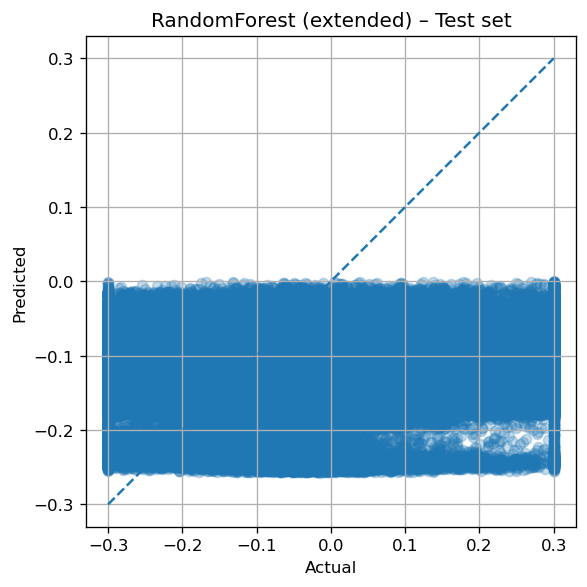

In [49]:
y_pred_test = pipe_rf_ext.predict(X_test)
plot_pred_vs_actual(y_test, y_pred_test, title='RandomForest (extended) – Test set')

## 10. Nonlinear CAPM curve for `Mkt-RF`

Hold all features at their median levels (in the training period), and vary `Mkt-RF` across its historical range to see the implied **nonlinear CAPM curve** from the Random Forest model.

If your dataset does not contain `Mkt-RF`, this cell will raise a clear error message.

/opt/anaconda3/envs/fyp312/lib/python3.12/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['price' 'd12' 'e12' 'retx' 'AAA' 'BAA' 'lty' 'ltr' 'corpr' 'tbl' 'Rfree'
 'd/p' 'd/y' 'e/p' 'd/e' 'b/m' 'tms' 'dfy' 'dfr' 'infl' 'eqis' 'ntis'
 'svar' 'cay' 'i/k' 'csp' 'pce' 'vp' 'impvar' 'vrp' 'govik' 'lzrt' 'skew'
 'crdstd' 'ogap' 'wtexas' 'accrul' 'cfacc' 'sntm' 'ndrbl' 'skvw' 'tail'
 'fbm' 'dtoy' 'dtoat' 'ygap' 'rdsp' 'rsvix' 'gpce' 'gip' 'tchi' 'house'
 'avgcor' 'shtint' 'disag']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


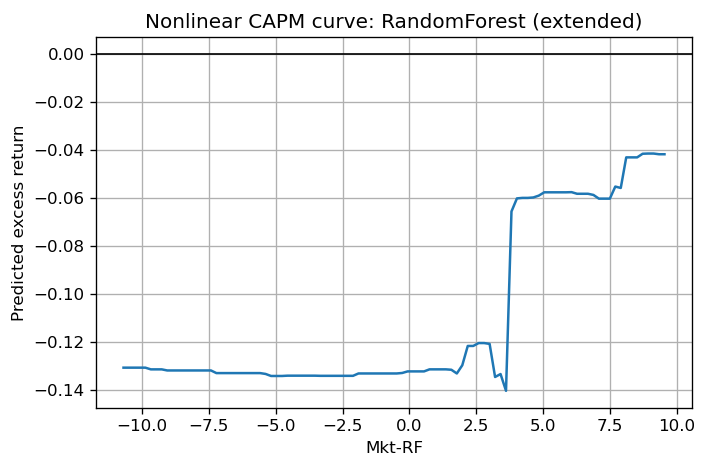

In [50]:
capm_curve_plot(pipe_rf_ext, X_train, feature_name='Mkt-RF', model_name='RandomForest (extended)')